In [1]:
# ================= PORT NA KONWENCJE ARTYKULU (06.09.2026) =================
# Ten notebook jest PORTEM 20260902b.ipynb. Analiza, generatory surogatow, reguly
# odczytu i wykresy sa NIETKNIETE - zmienila sie WYLACZNIE konwencja
# binowania (komorka ze statystyka liczy teraz przez ../statystyka.py w
# konwencji kodu zespolu) oraz nazwy plikow: wejsciowe finetune_* -> credo_*,
# wyjsciowe dostaly przedrostek credo_, zeby nic ze starych wynikow nie
# zostalo nadpisane. Powod i walidacja: dziennik 20260905.txt pkt 13a-13g
# oraz 20260906a.ipynb.
# ==========================================================================

# 02.09.2026 - 20260902b.ipynb: FIG.4 NA DANYCH ZABURZONYCH.
#
# JEDEN watek: czy wykres z Fig.4 artykulu - ciag glebokich minimow w rytmie
# ~10 lat - odtwarza sie na katalogu, w ktorym nie ma zadnej struktury
# sejsmicznej poza rocznym tempem zdarzen. I czy ten rytm znika, gdy usunac
# z katalogu sam trend wieloletni.
#
# 20260902a.ipynb odpowiedzial na pytanie ILOSCIOWE (rozklad zerowy istotnosci).
# Ten notebook odpowiada na pytanie JAKOSCIOWE, w konwencji samego artykulu, i
# dokłada kontrole, ktorej 01.09 zabraklo. Wynik ma byc czytelny dla kogos, kto
# nie przeczyta tabeli - dlatego osie sa dokladnie takie jak w Fig.4.
#
# TRZY WERSJE KATALOGU, kazda przepuszczona przez ten sam skan:
#
#  (1) PRAWDZIWY - odniesienie.
#
#  (2) SUROGAT Z TRENDEM - dla kazdego roku dokladnie tyle zdarzen, ile bylo
#      naprawde, magnitudy losowane z tego samego roku, czasy losowe w obrebie
#      roku. Zachowany: caly wieloletni trend detekcyjny katalogu. Zniszczone:
#      wszystko krotsze niz rok, w tym jakikolwiek mozliwy zwiazek CR-EQ.
#
#  (3) SUROGAT BEZ TRENDU - ta sama LACZNA liczba zdarzen, ale rozlozona
#      JEDNOSTAJNIE po calym zakresie katalogu, wiec roczne tempo jest plaskie.
#      Magnitudy losowane z calego katalogu.
#      TO JEST KONTROLA, KTOREJ ZABRAKLO 01.09. Wtedy trend usuwano przez
#      podniesienie progu magnitudy albo przez przerzedzanie katalogu - obie
#      metody usuwaly trend, ale RAZEM z gestoscia zdarzen (z ~192 zdarzen na
#      kosz robilo sie ~7), wiec nie dalo sie orzec, czy minima znikaja przez
#      jednorodnosc, czy przez rzadkosc. Dziennik 01.09 nazwal ten wynik wprost
#      nierozstrzygajacym. Tutaj zdarzen nie wyrzucamy, tylko je PRZESUWAMY -
#      gestosc zostaje taka sama, znika wylacznie trend. To rozdziela obie
#      rzeczy czysto.
#
# REGULY ODCZYTU - USTALONE PRZED ZOBACZENIEM WYNIKU:
#   A. Surogat Z TRENDEM odtwarza minima (liczbe i mniej wiecej daty), surogat
#      BEZ TRENDU ich nie ma  ->  rytm z Fig.4 wymaga wieloletniego trendu
#      katalogu i nie wymaga niczego sejsmicznego. Najmocniejszy mozliwy wynik
#      dla hipotezy artefaktu.
#   B. Obie wersje surogatu odtwarzaja minima  ->  trend nie jest potrzebny,
#      a artefakt siedzi po stronie CR (przeszukiwanie t0 wzgledem krzywej o
#      ksztalcie cyklu slonecznego). Wniosek jeszcze bardziej deflacyjny niz
#      dotychczasowy, ale INNY - trzeba by przepisac uzasadnienie z 01.09.
#   C. Zadna wersja surogatu nie odtwarza minimow  ->  wynik z 20260901e i z
#      20260902a byl artefaktem zgrubnej siatki albo doboru statystyki; caly
#      dotychczasowy wniosek do rewizji.
#
# UWAGA O TYM, CZEGO TEN NOTEBOOK NIE ROZSTRZYGA: surogat z trendem niszczy
# takze grupowanie wstrzasow wtornych. Jesli wiec wyjdzie mocniejszy od
# prawdziwego katalogu (a w 20260902a wyszedl mocniejszy 500 razy na 500), to
# NIE dowodzi jeszcze, ze krotkoterminowa struktura sejsmiczna "dziala
# przeciw" efektowi - dokladnie tak samo zachowywalby sie zwykly szum
# rozcienczajacy zgodnosc znakow. Rozstrzyga to dopiero surogat zachowujacy
# klastrowanie (przesuniecie cykliczne w obrebie roku), zaplanowany osobno.
#
# STACJA: mosc - to jest stacja z Fig.4 artykulu. Zmiana STACJA na "hrms"
# przelicza wszystko dla naszej najsilniejszej stacji, koszt ten sam.
#
# KOSZT [oszacowanie]: 74 tys. punktow t0 na krzywa, ~15 s na krzywa;
# 1 prawdziwa + 2 x 50 surogatowych to okolo 2-3 minut na 20 rdzeniach.
import json
import os
import sys
import time

import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import binom, norm

sys.path.insert(0, "..")
from mc_parallel import run_jobs_parallel

RESULTS_DIR = "../results"
DATA_DIR = "../data"
USGS_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"
MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"
EXTENDED_DIR = f"{DATA_DIR}/csv_data_stations_extended"
FULL6H_DIR = f"{DATA_DIR}/csv_data_stations_full6h"
SILSO_PATH = f"{DATA_DIR}/SN_m_tot_V2.0.csv"

P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS = 3350, 5, 4.0, 15
PROG_WYSOKOSCI = 5.0
STACJA = "mosc"
N_KRZYWYCH = 50          # realizacji kazdego typu surogatu
N_NA_WYKRESIE = 3        # ile realizacji rysujemy (reszta wchodzi do statystyki dat)
ZIARNO_BAZOWE = 20260902

# Piec dat t0 wypisanych wprost w sekcji 4 artykulu, z ich PPDF.
DATY_ARTYKULU = pd.DataFrame({
    "t0": pd.to_datetime(["1969-07-12 07:37:12", "1978-07-11 07:37:12",
                          "1988-09-21 07:37:12", "1999-12-23 07:37:12",
                          "2009-02-23 07:37:12"]),
    "PPDF": [3.3e-08, 3.0e-06, 3.6e-05, 2.9e-06, 8.1e-09]})


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_station(station):
    ext = os.path.join(EXTENDED_DIR, f"{station.lower()}_extended_6h.csv")
    full = os.path.join(FULL6H_DIR, f"{station.lower()}_full_6h.csv")
    df = pd.read_csv(ext if os.path.exists(ext) else full)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_plamy():
    """Miesieczna liczba plam slonecznych (SILSO), wygladzona oknem 13-miesiecznym
    - konwencja rysunkowa artykulu."""
    d = pd.read_csv(SILSO_PATH, sep=";")
    d = d[d["sunspot"] >= 0]
    czas = pd.to_datetime(dict(year=d["rok"], month=d["miesiac"], day=15))
    s = pd.Series(d["sunspot"].to_numpy(), index=czas).sort_index()
    return s.rolling(13, center=True, min_periods=7).mean()


katalog = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
katalog["time"] = pd.to_datetime(katalog["time"], utc=True).dt.tz_localize(None)
katalog = katalog[katalog["mag"] >= M_THRESHOLD].sort_values("time").reset_index(drop=True)
cr = load_mosc() if STACJA == "mosc" else load_station(STACJA)
plamy = load_plamy()
print(f"Katalog USGS M>={M_THRESHOLD}: {len(katalog)} zdarzen, "
      f"{katalog['time'].min().date()} .. {katalog['time'].max().date()}")
print(f"CR {STACJA}: {len(cr)} pomiarow, {cr.index.min().date()} .. {cr.index.max().date()}")
print(f"Plamy sloneczne: {len(plamy)} miesiecy, "
      f"{plamy.index.min().date()} .. {plamy.index.max().date()}")

Katalog USGS M>=4.0: 507919 zdarzen, 1965-01-01 .. 2025-01-31
CR mosc: 91824 pomiarow, 1960-01-01 .. 2025-03-23
Plamy sloneczne: 3330 miesiecy, 1749-01-15 .. 2026-06-15


In [2]:
# STATYSTYKA - w tym miejscu byla kopia funkcji, ta sama co w osmiu innych
# notebookach. Od 06.09 caly repo liczy przez wspolny modul ../statystyka.py,
# w KONWENCJI ARTYKULU: okno o jeden kosz przed t0, krata zakotwiczona w
# pierwszym dostepnym rekordzie (efektywne dt ok. 14,8 dnia zamiast 15),
# mediany po filtrze, filtr skrocony, remisy w mianowniku. Uzasadnienie:
# 20260905c.ipynb i dziennik 20260905.txt pkt 13a-13g; walidacja modulu
# (odtworzenie tabeli koszy zespolu kosz w kosz): 20260906a.ipynb.
#
# Nazwy przygotuj_szereg / przygotuj_katalog / y_krzywa zostaja te same, zeby
# reszta notebooka byla NIETKNIETA - to jest port konwencji, a nie nowa analiza.
sys.path.insert(0, "..")
import importlib

import statystyka as st
importlib.reload(st)   # statystyka.py jest w trakcie rozwoju; bez reload jadro
                       # trzyma wersje z pierwszego importu i zmiany na dysku sa
                       # niewidoczne az do restartu kernela

KONWENCJA = st.CREDO
OKNO = st.okno(P_DAYS, D_DAYS, DT_DAYS, KONWENCJA)
przygotuj_szereg = st.przygotuj_szereg
przygotuj_katalog = st.przygotuj_katalog


# MAX_JITTER_D - higiena skanu, nie zmiana statystyki. Kotwiczenie na danych
# (konwencja zespolu) przy skanie po calej historii cicho przenosi okno przez
# dziury w szeregu CR: liczylibysmy wtedy okno przesuniete o dlugosc dziury, a
# wynik wygladalby na policzony. Punkty, w ktorych efektywne dt odbiega od
# nominalnego o wiecej niz szerokosc kosza, dostaja NaN - tak samo jak punkty
# bez danych w starej konwencji. Uzasadnienie: docstring statystyka.krzywa i
# dziennik 20260906.txt sekcja 9.
MAX_JITTER_D = D_DAYS


def y_krzywa(cr_prep, eq_prep, siatka_ns):
    return st.krzywa(cr_prep, eq_prep, siatka_ns, OKNO, max_jitter_d=MAX_JITTER_D)[0]


print(f"Konwencja: {KONWENCJA}")
print(f"Okno: P = {P_DAYS} d, d = {D_DAYS} d, dt = {DT_DAYS} d -> "
      f"{OKNO.n_koszy} koszy, {OKNO.n_koszy - 1} par "
      f"(stara konwencja miala {int(P_DAYS // D_DAYS)} koszy, "
      f"{int(P_DAYS // D_DAYS) - 1} par)")


siatka = pd.read_csv(f"{RESULTS_DIR}/credo_{STACJA}_P3350_d5_dt15_fullhistory.csv",
                     usecols=["t0"], parse_dates=["t0"])["t0"].sort_values().reset_index(drop=True)
siatka_ns = siatka.values.astype("datetime64[ns]").astype(np.int64)
cr_prep = przygotuj_szereg(cr)
KROK_DNI = (siatka.iloc[1] - siatka.iloc[0]) / pd.Timedelta(days=1)
DISTANCE = int(round(P_DAYS / KROK_DNI))
PODPROBKA = int(round(1 / KROK_DNI))     # co ile punktow zapisujemy krzywa (1/dzien)
print(f"Siatka t0: {len(siatka)} punktow, krok {KROK_DNI * 24:.0f} h, "
      f"{siatka.iloc[0].date()} .. {siatka.iloc[-1].date()}")
print(f"find_peaks: prog {PROG_WYSOKOSCI}, distance {DISTANCE} probek (= {P_DAYS} dni)")

def skan_krzywej(cr_prep, eq_prep, siatka_ns):
    # ODTWORZONA PO PORCIE. W oryginale (20260902b) byla to wlasna petla po
    # siatce zwracajaca PPDF; tutaj liczy ja modul, z tym samym progiem higieny
    # co y_krzywa. Zwraca PPDF (nie -log10), bo tak uzywa jej reszta notebooka.
    y, _Np, _Nm, _N, _dt = st.krzywa(cr_prep, eq_prep, siatka_ns, OKNO,
                                     max_jitter_d=MAX_JITTER_D)
    return np.power(10.0, -y)

Konwencja: Konwencja(kotwica='dane', wiodacy_kosz=True, mediany='po_filtrze', filtr='skrocony', remisy='w_N')
Okno: P = 3350 d, d = 5 d, dt = 15 d -> 671 koszy, 670 par (stara konwencja miala 670 koszy, 669 par)
Siatka t0: 74322 punktow, krok 6 h, 1965-01-01 .. 2015-11-15
find_peaks: prog 5.0, distance 13400 probek (= 3350 dni)


In [3]:
# TRZY GENERATORY KATALOGU.
#
# Wspolna zasada dla obu surogatow: zdarzen nie ubywa ani nie przybywa. Rozni
# je tylko to, czy zachowuja wieloletni trend detekcyjny.
_KAT_OD, _KAT_DO = katalog["time"].min(), katalog["time"].max()
_LATA = {int(r): g["mag"].to_numpy() for r, g in katalog.groupby(katalog["time"].dt.year)}
_GRANICE_LAT = {}
for _r in _LATA:
    _od = max(pd.Timestamp(year=_r, month=1, day=1), _KAT_OD)
    _do = min(pd.Timestamp(year=_r + 1, month=1, day=1), _KAT_DO)
    _GRANICE_LAT[_r] = (_od, (_do - _od).total_seconds())
_WSZYSTKIE_MAG = katalog["mag"].to_numpy()
_ZAKRES_S = (_KAT_DO - _KAT_OD).total_seconds()


def _posprzataj(czasy, magnitudy):
    s = pd.DataFrame(dict(time=czasy, mag=magnitudy)).sort_values("time").reset_index(drop=True)
    # Losowane czasy maja rozdzielczosc nanosekundowa, a krawedzie koszy
    # mikrosekundowa - zaokraglamy do pelnych sekund (przy koszach 5-dniowych
    # bez znaczenia), jak w 20260901e/20260902a.
    s["time"] = s["time"].dt.floor("s").astype("datetime64[us]")
    return s


def surogat_z_trendem(ziarno):
    """Roczne tempo zachowane co do jednego zdarzenia; czasy losowe w roku."""
    rng = np.random.default_rng(ziarno)
    cz, mg = [], []
    for rok, magi in _LATA.items():
        poczatek, dlugosc = _GRANICE_LAT[rok]
        cz.append(poczatek + pd.to_timedelta(rng.uniform(0, dlugosc, len(magi)), unit="s"))
        mg.append(rng.choice(magi, size=len(magi), replace=True))
    return _posprzataj(np.concatenate(cz), np.concatenate(mg))


def surogat_bez_trendu(ziarno):
    """Ta sama LACZNA liczba zdarzen, rozlozona jednostajnie po calym zakresie
    katalogu - roczne tempo plaskie, gestosc niezmieniona."""
    rng = np.random.default_rng(ziarno)
    n = len(katalog)
    czasy = _KAT_OD + pd.to_timedelta(rng.uniform(0, _ZAKRES_S, n), unit="s")
    return _posprzataj(czasy, rng.choice(_WSZYSTKIE_MAG, size=n, replace=True))


# Kontrola obu generatorow: pokazujemy WPROST, ze rozni je tylko trend.
_a, _b = surogat_z_trendem(ZIARNO_BAZOWE), surogat_bez_trendu(ZIARNO_BAZOWE)
print(f"{'wersja katalogu':22s} {'zdarzen':>8s} {'zdarzen/kosz':>13s} "
      f"{'tempo 2005-2014 / 1970-1979':>28s}")
for nazwa, kat in [("prawdziwy", katalog), ("surogat z trendem", _a),
                   ("surogat bez trendu", _b)]:
    r1 = len(kat[(kat["time"] >= "1970") & (kat["time"] < "1980")]) / 10
    r2 = len(kat[(kat["time"] >= "2005") & (kat["time"] < "2015")]) / 10
    na_kosz = len(kat) / ((_KAT_DO - _KAT_OD).days / D_DAYS)
    print(f"{nazwa:22s} {len(kat):8d} {na_kosz:13.1f} {r2 / r1:28.2f}")
print()
print("Odczyt tej tabeli: wszystkie trzy wersje maja te sama liczbe zdarzen i te")
print("sama srednia gestosc na kosz. Rozni je WYLACZNIE ostatnia kolumna, czyli")
print("stosunek tempa dekady 2005-2014 do dekady 1970-1979 - a to jest wlasnie")
print("wieloletni trend detekcyjny. Kontrola z 01.09 tego nie potrafila rozdzielic.")
print()
_por = pd.DataFrame({"prawdziwy": katalog.groupby(katalog["time"].dt.year).size(),
                     "z_trendem": _a.groupby(_a["time"].dt.year).size()})
print(f"Surogat z trendem, najwieksza roznica rocznej liczby zdarzen: "
      f"{int((_por['z_trendem'] - _por['prawdziwy']).abs().max())} (ma byc 0)")

wersja katalogu         zdarzen  zdarzen/kosz  tempo 2005-2014 / 1970-1979
prawdziwy                507919         115.7                         4.36
surogat z trendem        507919         115.7                         4.36
surogat bez trendu       507919         115.7                         1.00

Odczyt tej tabeli: wszystkie trzy wersje maja te sama liczbe zdarzen i te
sama srednia gestosc na kosz. Rozni je WYLACZNIE ostatnia kolumna, czyli
stosunek tempa dekady 2005-2014 do dekady 1970-1979 - a to jest wlasnie
wieloletni trend detekcyjny. Kontrola z 01.09 tego nie potrafila rozdzielic.

Surogat z trendem, najwieksza roznica rocznej liczby zdarzen: 0 (ma byc 0)


In [4]:
# Skan wszystkich krzywych. Jedno zadanie = jedna krzywa.
SCIEZKA_KRZYWE = f"{RESULTS_DIR}/credo_fig4_zaburzone_krzywe_{STACJA}.csv"
SCIEZKA_MINIMA = f"{RESULTS_DIR}/credo_fig4_zaburzone_minima_{STACJA}.csv"
SCIEZKA_KONFIG = f"{RESULTS_DIR}/credo_fig4_zaburzone_config_{STACJA}.json"
PRZELICZ_OD_NOWA = False


def biezaca_konfiguracja():
    return dict(STACJA=STACJA, P_DAYS=P_DAYS, D_DAYS=D_DAYS, DT_DAYS=DT_DAYS,
                M_THRESHOLD=M_THRESHOLD, PROG_WYSOKOSCI=PROG_WYSOKOSCI,
                DISTANCE=DISTANCE, PODPROBKA=PODPROBKA,
                N_KRZYWYCH=N_KRZYWYCH, ZIARNO_BAZOWE=ZIARNO_BAZOWE,
                katalog_n=int(len(katalog)),
                katalog_zakres=[str(_KAT_OD), str(_KAT_DO)],
                siatka=[str(siatka.iloc[0]), str(siatka.iloc[-1]), int(len(siatka))])


def zadanie(job):
    typ, ziarno = job
    if typ == "prawdziwy":
        kat = katalog
    elif typ == "z_trendem":
        kat = surogat_z_trendem(ziarno)
    else:
        kat = surogat_bez_trendu(ziarno)
    ppdf = skan_krzywej(cr_prep, przygotuj_szereg(kat.set_index("time")["mag"].sort_index()),
                        siatka_ns)
    y = -np.log10(ppdf)
    piki, _ = find_peaks(np.nan_to_num(y, nan=-1.0), height=PROG_WYSOKOSCI, distance=DISTANCE)
    return dict(typ=typ, ziarno=int(ziarno), n_minimow=int(len(piki)),
                minima_t0=";".join(str(d) for d in siatka.iloc[piki]),
                minima_wys=";".join(f"{v:.4f}" for v in y[piki]),
                max_krzywej=float(np.nanmax(y)),
                krzywa=[float(v) for v in y[::PODPROBKA]])


zadania = ([("prawdziwy", 0)]
           + [("z_trendem", ZIARNO_BAZOWE + i) for i in range(N_KRZYWYCH)]
           + [("bez_trendu", ZIARNO_BAZOWE + 10000 + i) for i in range(N_KRZYWYCH)])

wczytano = False
if not PRZELICZ_OD_NOWA and all(os.path.exists(p) for p in
                                (SCIEZKA_KRZYWE, SCIEZKA_MINIMA, SCIEZKA_KONFIG)):
    if json.load(open(SCIEZKA_KONFIG)) == biezaca_konfiguracja():
        krzywe = pd.read_csv(SCIEZKA_KRZYWE, parse_dates=["srodek_okna"])
        minima_tab = pd.read_csv(SCIEZKA_MINIMA)
        if len(minima_tab) == len(zadania):
            wczytano = True
            print(f"WCZYTANO gotowe krzywe z {SCIEZKA_KRZYWE} - nic nie liczono.")
    if not wczytano:
        print("Zapisane krzywe nie pasuja do biezacej konfiguracji - liczymy od nowa.")

if not wczytano:
    print(f"Skan: {len(zadania)} krzywych x {len(siatka)} punktow t0.")
    start = time.time()
    surowe = run_jobs_parallel(zadanie, zadania, opis="krzywych", raport_co=10)
    print(f"Czas calkowity: {(time.time() - start) / 60:.1f} min")
    # Konwencja rysunkowa Fig.4: os X to SRODEK okna, nie jego poczatek.
    srodki = siatka.iloc[::PODPROBKA].reset_index(drop=True) + pd.Timedelta(days=P_DAYS / 2)
    krzywe = pd.DataFrame({"srodek_okna": srodki})
    for r in surowe.itertuples():
        krzywe[f"{r.typ}_{r.ziarno}"] = r.krzywa
    krzywe.to_csv(SCIEZKA_KRZYWE, index=False)
    minima_tab = surowe.drop(columns=["krzywa"])
    minima_tab.to_csv(SCIEZKA_MINIMA, index=False)
    json.dump(biezaca_konfiguracja(), open(SCIEZKA_KONFIG, "w"), indent=1)
    print(f"Zapisano {SCIEZKA_KRZYWE} i {SCIEZKA_MINIMA}")

KOL_PRAWDZIWA = "prawdziwy_0"
KOL_TREND = [c for c in krzywe.columns if c.startswith("z_trendem_")]
KOL_PLASKI = [c for c in krzywe.columns if c.startswith("bez_trendu_")]
print(f"\nKrzywych: prawdziwa 1, z trendem {len(KOL_TREND)}, bez trendu {len(KOL_PLASKI)}")
print(f"Punktow na krzywej po podprobkowaniu: {len(krzywe)} (co {PODPROBKA * KROK_DNI:.0f} dzien)")

Skan: 101 krzywych x 74322 punktow t0.
  10/101 krzywych; minelo 1.4 min, zostalo ~12.5 min
  20/101 krzywych; minelo 1.5 min, zostalo ~6.0 min
  30/101 krzywych; minelo 2.7 min, zostalo ~6.5 min
  40/101 krzywych; minelo 3.0 min, zostalo ~4.5 min
  50/101 krzywych; minelo 4.0 min, zostalo ~4.1 min
  60/101 krzywych; minelo 4.2 min, zostalo ~2.8 min
  70/101 krzywych; minelo 5.1 min, zostalo ~2.2 min
  80/101 krzywych; minelo 5.2 min, zostalo ~1.4 min
  90/101 krzywych; minelo 6.1 min, zostalo ~0.7 min
  100/101 krzywych; minelo 6.2 min, zostalo ~0.1 min
  101/101 krzywych; minelo 6.3 min, zostalo ~0.0 min
Czas calkowity: 6.3 min


/tmp/ipykernel_12105/1679936250.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  krzywe[f"{r.typ}_{r.ziarno}"] = r.krzywa


Zapisano ../results/credo_fig4_zaburzone_krzywe_mosc.csv i ../results/credo_fig4_zaburzone_minima_mosc.csv

Krzywych: prawdziwa 1, z trendem 50, bez trendu 50
Punktow na krzywej po podprobkowaniu: 18581 (co 1 dzien)


In [5]:
# LICZBY: ile minimow i gdzie, w kazdej z trzech wersji katalogu.
def rozbij_minima(w):
    if not isinstance(w, str) or not w:
        return []
    return [pd.Timestamp(x) for x in w.split(";")]


minima_tab["daty"] = minima_tab["minima_t0"].apply(rozbij_minima)
praw = minima_tab[minima_tab.typ == "prawdziwy"].iloc[0]
daty_praw = praw["daty"]

print("KATALOG PRAWDZIWY")
print(f"  minimow powyzej progu {PROG_WYSOKOSCI}: {praw['n_minimow']}")
print(f"  daty t0: {', '.join(str(d.date()) for d in daty_praw)}")
if len(daty_praw) > 1:
    ods = np.diff([d.value for d in daty_praw]) / (86400e9 * 365.25)
    print(f"  odstepy [lata]: {', '.join(f'{o:.1f}' for o in ods)} (mediana {np.median(ods):.1f})")
print()

for typ, opis in [("z_trendem", "SUROGAT Z TRENDEM (roczne tempo prawdziwe, "
                                "reszta losowa)"),
                  ("bez_trendu", "SUROGAT BEZ TRENDU (tempo plaskie, ta sama gestosc)")]:
    g = minima_tab[minima_tab.typ == typ]
    liczby = g["n_minimow"].value_counts().sort_index()
    print(opis)
    print(f"  liczba minimow w {len(g)} realizacjach: "
          f"{', '.join(f'{k} minimow w {v} realizacjach' for k, v in liczby.items())}")
    print(f"  srednia {g['n_minimow'].mean():.2f}, "
          f"najglebsze minimum: mediana {g['max_krzywej'].median():.2f}, "
          f"maksimum {g['max_krzywej'].max():.2f}")
    wszystkie = [d for lista in g["daty"] for d in lista]
    if wszystkie:
        ods = [np.diff([d.value for d in lista]) / (86400e9 * 365.25)
               for lista in g["daty"] if len(lista) > 1]
        ods = np.concatenate(ods) if ods else np.array([])
        if len(ods):
            print(f"  odstepy miedzy minimami [lata]: mediana {np.median(ods):.1f}, "
                  f"kwartyle {np.percentile(ods, 25):.1f}-{np.percentile(ods, 75):.1f}")
    print()

# ZGODNOSC DAT. To jest pytanie, ktore decyduje o sile wniosku: czy surogat
# odtwarza tylko LICZBE minimow (wtedy Fig.4 jest odtworzona slabo, bo bez
# fazy), czy takze ich POLOZENIE (wtedy odtworzona jest cala struktura).
print("ZGODNOSC DAT: dla kazdego minimum prawdziwego - w ilu realizacjach")
print("surogatu z trendem znalazlo sie minimum w promieniu 1 roku:")
for d in daty_praw:
    trafienia = sum(any(abs((x - d).days) <= 365 for x in lista)
                    for lista in minima_tab[minima_tab.typ == "z_trendem"]["daty"])
    print(f"  {d.date()}: {trafienia}/{len(KOL_TREND)} realizacji "
          f"({100 * trafienia / len(KOL_TREND):.0f}%)")

KATALOG PRAWDZIWY
  minimow powyzej progu 5.0: 5
  daty t0: 1968-03-24, 1978-05-24, 1989-03-03, 1999-02-18, 2008-08-08
  odstepy [lata]: 10.2, 10.8, 10.0, 9.5 (mediana 10.1)

SUROGAT Z TRENDEM (roczne tempo prawdziwe, reszta losowa)
  liczba minimow w 50 realizacjach: 4 minimow w 2 realizacjach, 5 minimow w 48 realizacjach
  srednia 4.96, najglebsze minimum: mediana 12.37, maksimum 16.03
  odstepy miedzy minimami [lata]: mediana 10.6, kwartyle 9.9-11.2

SUROGAT BEZ TRENDU (tempo plaskie, ta sama gestosc)
  liczba minimow w 50 realizacjach: 0 minimow w 35 realizacjach, 1 minimow w 13 realizacjach, 2 minimow w 2 realizacjach
  srednia 0.34, najglebsze minimum: mediana 4.63, maksimum 7.20
  odstepy miedzy minimami [lata]: mediana 22.3, kwartyle 21.9-22.7

ZGODNOSC DAT: dla kazdego minimum prawdziwego - w ilu realizacjach
surogatu z trendem znalazlo sie minimum w promieniu 1 roku:
  1968-03-24: 50/50 realizacji (100%)
  1978-05-24: 50/50 realizacji (100%)
  1989-03-03: 50/50 realizacji (10

Zapisano ../results/credo_fig4_zaburzone_1_prawdziwy_mosc.png

Uwaga do odczytu: czerwone znaczniki to wartosci PPDF WYPISANE W ARTYKULE,
a nie policzone przez nas. Rozbieznosc miedzy nimi a nasza krzywa w tych
samych datach jest znanym, nierozstrzygnietym punktem (patrz
results/article_section4_point_eval.csv i dziennik 01.09) i NIE jest
przedmiotem tego notebooka.


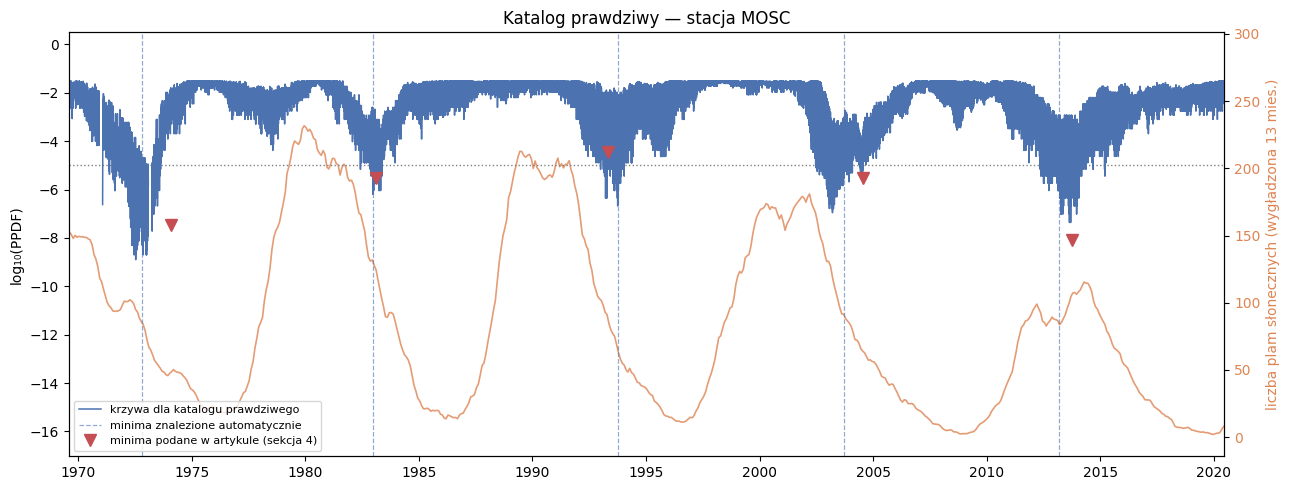

In [6]:
# WYKRES 1 (jedno kodowanie: wysokosc krzywej) - Fig.4 dla katalogu
# PRAWDZIWEGO, w konwencji artykulu: os X to srodek okna, os Y to log10(PPDF)
# (minima w dol), plamy sloneczne wygladzone oknem 13-miesiecznym na osi
# pomocniczej. To jest punkt odniesienia dla dwoch nastepnych wykresow -
# wszystkie trzy maja te same osie, zeby porownanie bylo bezposrednie.
import matplotlib.pyplot as plt

X_LIM = (krzywe["srodek_okna"].min(), krzywe["srodek_okna"].max())
Y_LIM = (-float(np.nanmax(krzywe[[KOL_PRAWDZIWA] + KOL_TREND + KOL_PLASKI].to_numpy())) - 1, 0.5)


def szkielet_fig4(ax, tytul):
    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.axhline(-PROG_WYSOKOSCI, color="gray", ls=":", lw=1)
    ax.set_ylabel("log₁₀(PPDF)")
    ax.set_title(tytul)
    ax2 = ax.twinx()
    ax2.plot(plamy.index, plamy.to_numpy(), color="#DD8452", lw=1.2, alpha=0.8)
    ax2.set_ylabel("liczba plam słonecznych (wygładzona 13 mies.)", color="#DD8452")
    ax2.tick_params(axis="y", labelcolor="#DD8452")
    ax2.set_zorder(0)
    ax.set_zorder(1)
    ax.patch.set_visible(False)
    return ax2


fig, ax = plt.subplots(figsize=(13, 5))
szkielet_fig4(ax, f"Katalog prawdziwy — stacja {STACJA.upper()}")
ax.plot(krzywe["srodek_okna"], -krzywe[KOL_PRAWDZIWA], color="#4C72B0", lw=1.1,
        label="krzywa dla katalogu prawdziwego")
for i, d in enumerate(daty_praw):
    ax.axvline(d + pd.Timedelta(days=P_DAYS / 2), color="#4C72B0", ls="--", lw=0.9,
               alpha=0.6, label="minima znalezione automatycznie" if i == 0 else None)
for i, r in enumerate(DATY_ARTYKULU.itertuples()):
    ax.plot(r.t0 + pd.Timedelta(days=P_DAYS / 2), np.log10(r.PPDF), "v", color="#C44E52",
            ms=9, label="minima podane w artykule (sekcja 4)" if i == 0 else None)
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_fig4_zaburzone_1_prawdziwy_{STACJA}.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_fig4_zaburzone_1_prawdziwy_{STACJA}.png")
print()
print("Uwaga do odczytu: czerwone znaczniki to wartosci PPDF WYPISANE W ARTYKULE,")
print("a nie policzone przez nas. Rozbieznosc miedzy nimi a nasza krzywa w tych")
print("samych datach jest znanym, nierozstrzygnietym punktem (patrz")
print("results/article_section4_point_eval.csv i dziennik 01.09) i NIE jest")
print("przedmiotem tego notebooka.")

Zapisano ../results/credo_fig4_zaburzone_2_z_trendem_mosc.png


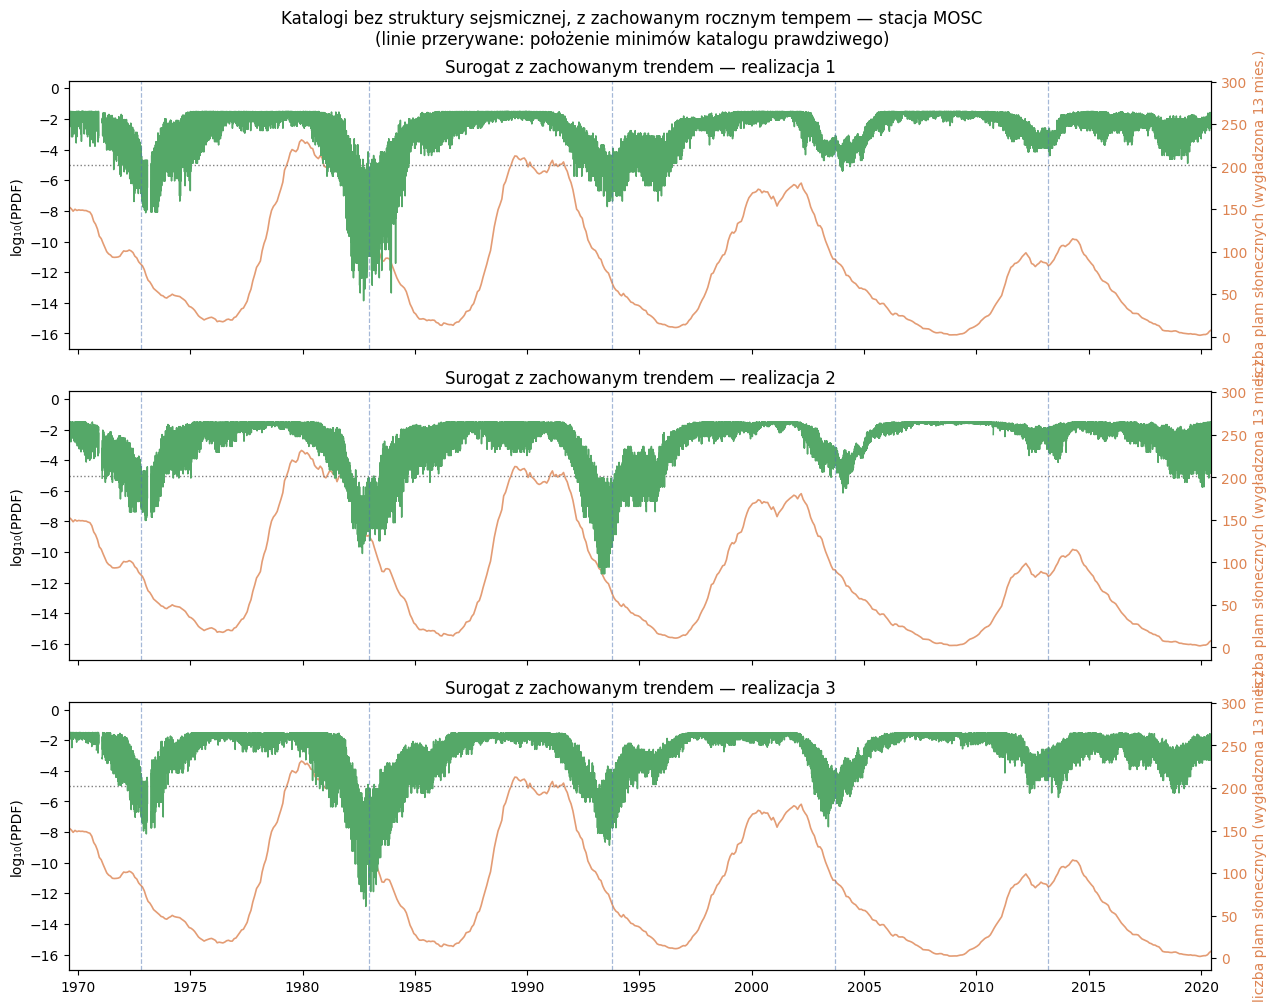

In [7]:
# WYKRES 2 (jedno kodowanie: wysokosc krzywej) - to samo dla katalogow
# SUROGATOWYCH Z TRENDEM. Kazda realizacja w osobnym panelu, te same osie co
# wykres 1. Zadna z tych krzywych nie ma prawa "wiedziec" nic o trzesieniach
# ziemi poza tym, ile ich bylo w danym roku.
fig, osie = plt.subplots(N_NA_WYKRESIE, 1, figsize=(13, 3.4 * N_NA_WYKRESIE), sharex=True)
for i, (ax, kol) in enumerate(zip(np.atleast_1d(osie), KOL_TREND[:N_NA_WYKRESIE])):
    szkielet_fig4(ax, f"Surogat z zachowanym trendem — realizacja {i + 1}")
    ax.plot(krzywe["srodek_okna"], -krzywe[kol], color="#55A868", lw=1.1)
    for d in daty_praw:
        ax.axvline(d + pd.Timedelta(days=P_DAYS / 2), color="#4C72B0", ls="--",
                   lw=0.9, alpha=0.5)
fig.suptitle(f"Katalogi bez struktury sejsmicznej, z zachowanym rocznym tempem "
             f"— stacja {STACJA.upper()}\n"
             f"(linie przerywane: położenie minimów katalogu prawdziwego)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_fig4_zaburzone_2_z_trendem_{STACJA}.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_fig4_zaburzone_2_z_trendem_{STACJA}.png")

Zapisano ../results/credo_fig4_zaburzone_3_bez_trendu_mosc.png


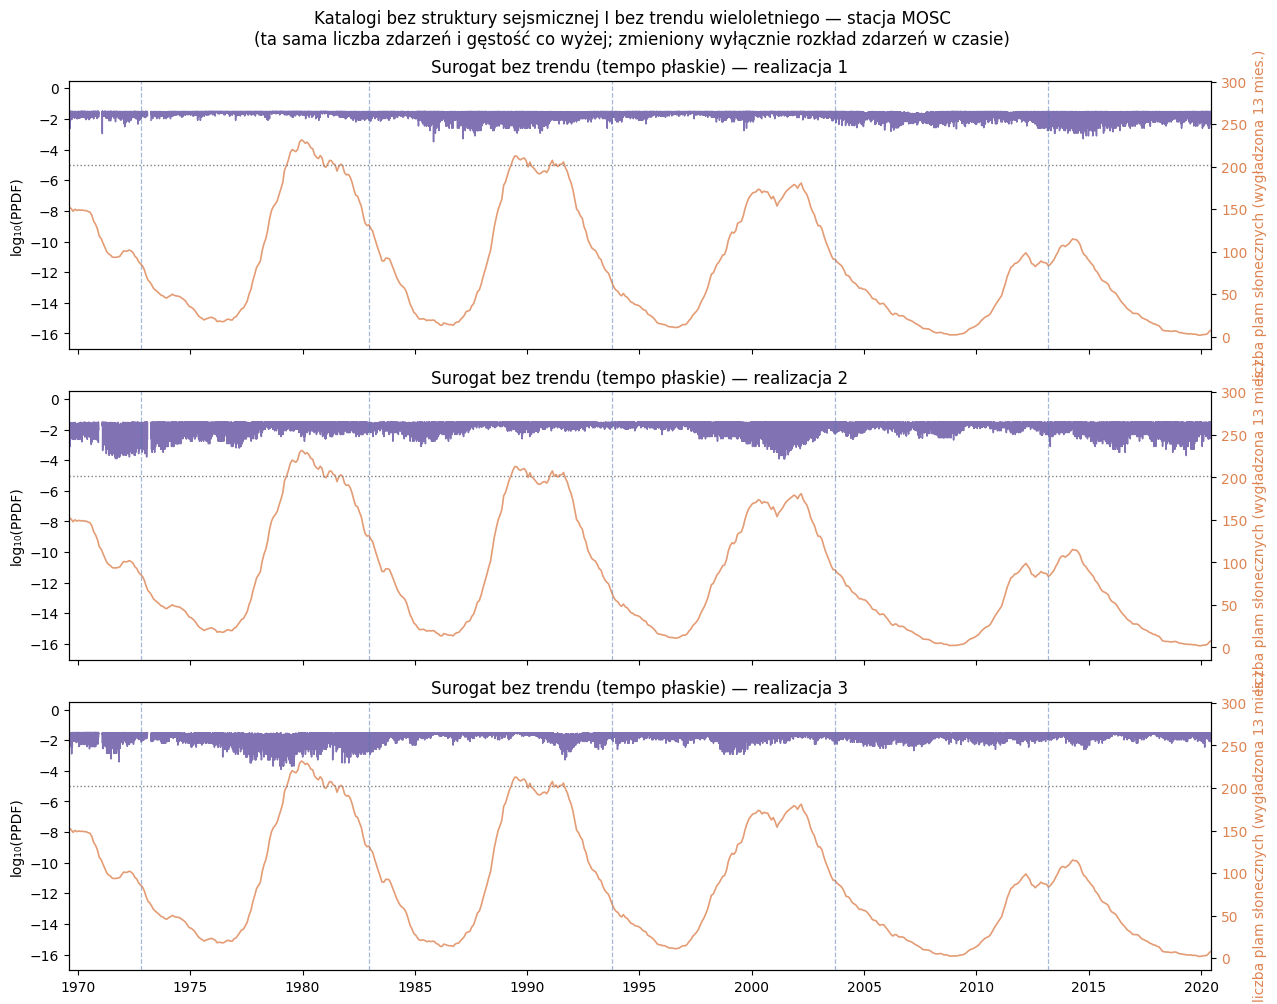

In [8]:
# WYKRES 3 (jedno kodowanie: wysokosc krzywej) - katalogi surogatowe BEZ
# TRENDU. Ta sama liczba zdarzen i ta sama gestosc co wyzej, zmienione tylko
# to, ze roczne tempo jest plaskie. Jesli minima tu znikaja, to trend
# wieloletni jest skladnikiem KONIECZNYM.
fig, osie = plt.subplots(N_NA_WYKRESIE, 1, figsize=(13, 3.4 * N_NA_WYKRESIE), sharex=True)
for i, (ax, kol) in enumerate(zip(np.atleast_1d(osie), KOL_PLASKI[:N_NA_WYKRESIE])):
    szkielet_fig4(ax, f"Surogat bez trendu (tempo płaskie) — realizacja {i + 1}")
    ax.plot(krzywe["srodek_okna"], -krzywe[kol], color="#8172B3", lw=1.1)
    for d in daty_praw:
        ax.axvline(d + pd.Timedelta(days=P_DAYS / 2), color="#4C72B0", ls="--",
                   lw=0.9, alpha=0.5)
fig.suptitle(f"Katalogi bez struktury sejsmicznej I bez trendu wieloletniego "
             f"— stacja {STACJA.upper()}\n"
             f"(ta sama liczba zdarzeń i gęstość co wyżej; zmieniony wyłącznie "
             f"rozkład zdarzeń w czasie)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_fig4_zaburzone_3_bez_trendu_{STACJA}.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_fig4_zaburzone_3_bez_trendu_{STACJA}.png")

Zapisano ../results/credo_fig4_zaburzone_4_daty_mosc.png


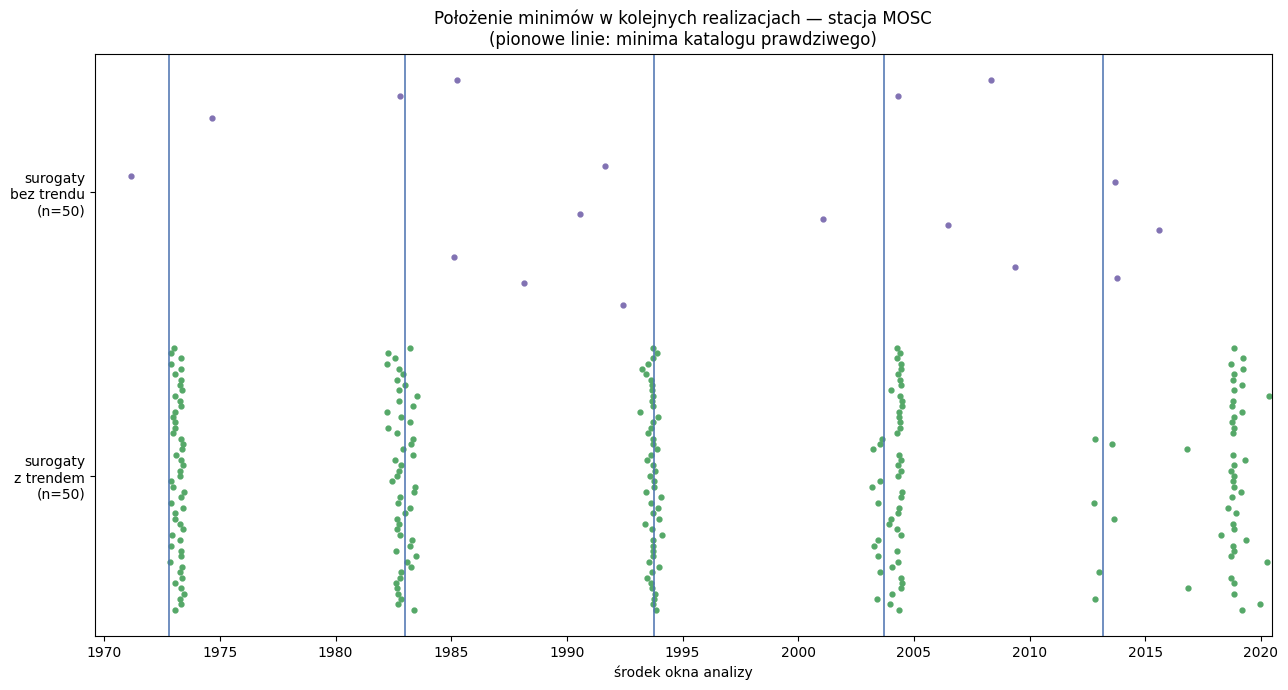

In [9]:
# WYKRES 4 (jedno kodowanie: polozenie znacznika na osi czasu) - GDZIE
# wypadaja minima. Kazdy wiersz to jedna realizacja, kazdy znacznik jedno
# minimum. Ten wykres odpowiada na pytanie o FAZE: czy surogat trafia w te same
# daty co katalog prawdziwy, czy tylko produkuje podobna ich liczbe.
fig, ax = plt.subplots(figsize=(13, 7))
for i, r in enumerate(minima_tab[minima_tab.typ == "z_trendem"].itertuples()):
    ax.plot([d + pd.Timedelta(days=P_DAYS / 2) for d in r.daty],
            [i] * len(r.daty), "o", color="#55A868", ms=3.5)
przesun = len(KOL_TREND) + 3
for i, r in enumerate(minima_tab[minima_tab.typ == "bez_trendu"].itertuples()):
    ax.plot([d + pd.Timedelta(days=P_DAYS / 2) for d in r.daty],
            [przesun + i] * len(r.daty), "o", color="#8172B3", ms=3.5)
for d in daty_praw:
    ax.axvline(d + pd.Timedelta(days=P_DAYS / 2), color="#4C72B0", lw=1.4, alpha=0.8)
ax.set_xlim(*X_LIM)
ax.set_yticks([len(KOL_TREND) / 2, przesun + len(KOL_PLASKI) / 2])
ax.set_yticklabels([f"surogaty\nz trendem\n(n={len(KOL_TREND)})",
                    f"surogaty\nbez trendu\n(n={len(KOL_PLASKI)})"])
ax.set_xlabel("środek okna analizy")
ax.set_title(f"Położenie minimów w kolejnych realizacjach — stacja {STACJA.upper()}\n"
             f"(pionowe linie: minima katalogu prawdziwego)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_fig4_zaburzone_4_daty_{STACJA}.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_fig4_zaburzone_4_daty_{STACJA}.png")

In [10]:
# PODSUMOWANIE, czytane wedlug regul ustalonych w komorce 0 PRZED liczeniem.
n_tr = minima_tab[minima_tab.typ == "z_trendem"]["n_minimow"]
n_pl = minima_tab[minima_tab.typ == "bez_trendu"]["n_minimow"]
gl_tr = minima_tab[minima_tab.typ == "z_trendem"]["max_krzywej"]
gl_pl = minima_tab[minima_tab.typ == "bez_trendu"]["max_krzywej"]

print("=" * 78)
print("FIG.4 NA DANYCH ZABURZONYCH - PODSUMOWANIE")
print("=" * 78)
print()
print(f"Katalog prawdziwy       : {praw['n_minimow']} minimow, "
      f"najglebsze {praw['max_krzywej']:.2f}")
print(f"Surogat z trendem       : {n_tr.mean():.2f} minimow srednio "
      f"(zakres {n_tr.min()}-{n_tr.max()}), najglebsze mediana {gl_tr.median():.2f}")
print(f"Surogat bez trendu      : {n_pl.mean():.2f} minimow srednio "
      f"(zakres {n_pl.min()}-{n_pl.max()}), najglebsze mediana {gl_pl.median():.2f}")
print()

odtwarza_trend = n_tr.median() >= praw["n_minimow"] - 1
znika_bez_trendu = n_pl.median() <= max(0, praw["n_minimow"] - 2)
if odtwarza_trend and znika_bez_trendu:
    print("ODCZYT: SCENARIUSZ A. Rytm minimow z Fig.4 odtwarza sie na katalogu bez")
    print("jakiejkolwiek struktury sejsmicznej, o ile zachowany jest wieloletni")
    print("trend detekcyjny, i ZNIKA, gdy ten trend usunac przy niezmienionej")
    print("liczbie i gestosci zdarzen. Trend jest skladnikiem koniecznym i")
    print("wystarczajacym; nic sejsmicznego nie jest potrzebne.")
elif odtwarza_trend and not znika_bez_trendu:
    print("ODCZYT: SCENARIUSZ B. Minima pojawiaja sie takze przy plaskim tempie,")
    print("wiec trend NIE jest konieczny - artefakt siedzi po stronie CR (skan po")
    print("t0 wzgledem krzywej o ksztalcie cyklu slonecznego). Uzasadnienie")
    print("wniosku z 01.09 wymaga przepisania, choc sam wniosek sie wzmacnia.")
else:
    print("ODCZYT: SCENARIUSZ C. Surogat z trendem NIE odtwarza minimow. To jest")
    print("sprzeczne z 20260901e i 20260902a - przed wyciagnieciem jakiegokolwiek")
    print("wniosku trzeba zrozumiec rozbieznosc.")
print()
print("CZEGO TEN NOTEBOOK NIE POKAZUJE:")
print("  - Nie pokazuje, ze krotkoterminowa struktura sejsmiczna 'dziala przeciw'")
print("    efektowi. To, ze surogat z trendem wypada mocniej od prawdziwego")
print("    katalogu (20260902a: 500 razy na 500), tlumaczy sie w calosci zwyklym")
print("    rozcienczeniem zgodnosci znakow przez szum klastrowania. Zeby odroznic")
print("    rozcienczenie od przeciwdzialania, potrzebny jest surogat ZACHOWUJACY")
print("    klastrowanie (przesuniecie cykliczne w obrebie roku) - osobny watek.")
print("  - Nie tlumaczy rozbieznosci miedzy nasza krzywa a wartosciami PPDF")
print("    wypisanymi w artykule dla tych samych dat (patrz wykres 1).")
print("  - Dotyczy jednej stacji. Zmiana STACJA na 'hrms' przelicza calosc.")

FIG.4 NA DANYCH ZABURZONYCH - PODSUMOWANIE

Katalog prawdziwy       : 5 minimow, najglebsze 9.72
Surogat z trendem       : 4.96 minimow srednio (zakres 4-5), najglebsze mediana 12.37
Surogat bez trendu      : 0.34 minimow srednio (zakres 0-2), najglebsze mediana 4.63

ODCZYT: SCENARIUSZ A. Rytm minimow z Fig.4 odtwarza sie na katalogu bez
jakiejkolwiek struktury sejsmicznej, o ile zachowany jest wieloletni
trend detekcyjny, i ZNIKA, gdy ten trend usunac przy niezmienionej
liczbie i gestosci zdarzen. Trend jest skladnikiem koniecznym i
wystarczajacym; nic sejsmicznego nie jest potrzebne.

CZEGO TEN NOTEBOOK NIE POKAZUJE:
  - Nie pokazuje, ze krotkoterminowa struktura sejsmiczna 'dziala przeciw'
    efektowi. To, ze surogat z trendem wypada mocniej od prawdziwego
    katalogu (20260902a: 500 razy na 500), tlumaczy sie w calosci zwyklym
    rozcienczeniem zgodnosci znakow przez szum klastrowania. Zeby odroznic
    rozcienczenie od przeciwdzialania, potrzebny jest surogat ZACHOWUJACY
    k